<a href="https://colab.research.google.com/github/Caosbot/Treinos_Python/blob/Machine_Learning/Yolov8_malaria_int.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Identificando GPU

In [ ]:
!nvidia-smi

Wed Jun  5 16:18:31 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 551.23                 Driver Version: 551.23         CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   46C    P0              9W /   50W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
CUDA_LAUNCH_BLOCKING=1

In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
def_Mostrar = True

In [ ]:
#Função para plot de uma imagem
def mostrar(img, titulo,map=None):
  global def_Mostrar
  if def_Mostrar:
    fig = plt.gcf()
    fig.set_size_inches(20, 10)
    # Verificar se a imagem é RGB ou grayscale
    if len(img.shape) == 3:
      plt.imshow(img, cmap=map)
    else:
      plt.imshow(img, cmap="gray")

    plt.title(titulo)
    plt.show()

# Bibliotecas

In [ ]:
#Para biblioteca do YOLO
#!pip install ultralytics

In [ ]:
from ultralytics import YOLO
import os
import cv2
import matplotlib.pyplot as plt
from datetime import datetime
import time

In [ ]:
# Obter data e hora atuais
data_hora_atual = datetime.now()

# Formatar a data e hora
print(data_hora_atual.strftime("%Y-%m-%d %H:%M:%S"))

2024-06-05 16:18:34


In [ ]:
print(cv2.__version__)

4.9.0


# Ajuste de caminhos

In [ ]:
#Caminho da pasta inicial
path= 'F:/Yolo_01_06_2024'

In [ ]:
#Aplica o caminho
%cd {path}

F:\Yolo_01_06_2024


In [ ]:
ls

 O volume na unidade F ‚ Jogos
 O N£mero de S‚rie do Volume ‚ D65B-C471

 Pasta de F:\Yolo_01_06_2024

05/06/2024  16:17    <DIR>          .
01/06/2024  11:06    <DIR>          Falciparum_WhiteCell
05/06/2024  16:17    <DIR>          Runs Antigas
01/06/2024  11:14               161 whitefalc.yaml
02/06/2024  22:03               148 whitefalc1.yaml
01/06/2024  11:20         6.534.387 yolov8n.pt
               3 arquivo(s)      6.534.696 bytes
               3 pasta(s)   283.995.189.248 bytes dispon¡veis


In [ ]:
path_dataset = path+'/Falciparum_WhiteCell/dataset'

In [ ]:
path_image_test= path_dataset+'/test/images/TF110_270'
path_image_test

'F:/Yolo_01_06_2024/Falciparum_WhiteCell/dataset/test/images/TF110_270'

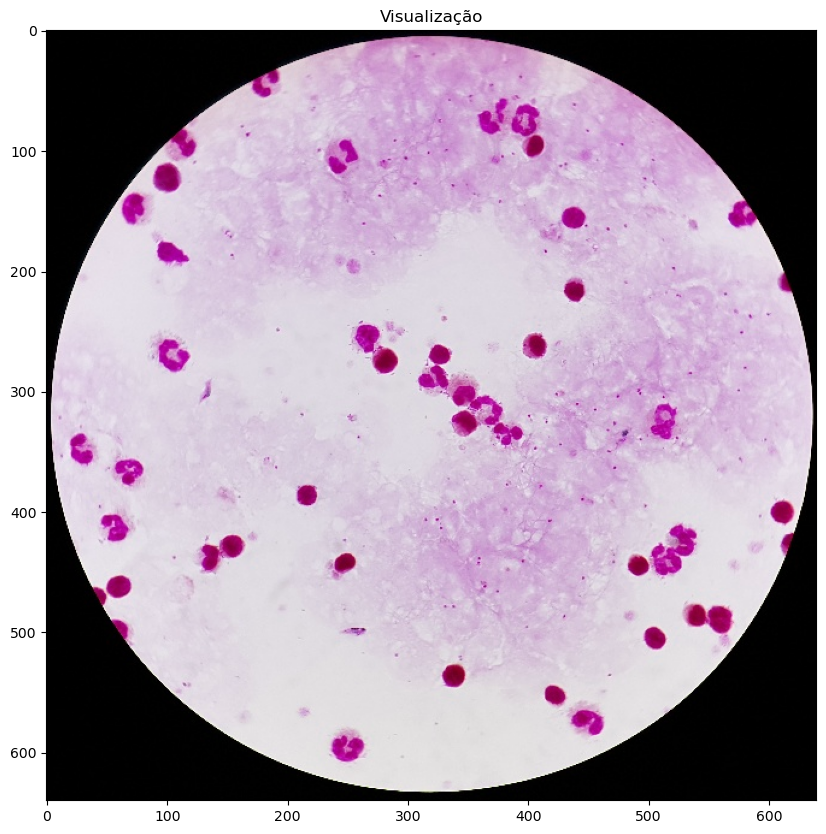

In [ ]:
mostrar(cv2.imread(f'{path_image_test}/20170830_170535.jpg'),"Visualização")

In [ ]:
#Prepara o caminho para acessar data.yaml
diretorio_raiz = path
arquivo_config = os.path.join(diretorio_raiz, 'whitefalc.yaml')

In [ ]:
nome='Falciparum_White'

# Treino Yolov8 Small, 50 epocas

In [ ]:
model = YOLO('yolov8n.yaml')

In [ ]:
#print('Já treinado 50 epocas')
inicio = time.time()
resultados = model.train(data=arquivo_config, epochs=100 , lr0=0.001 , patience=20 , cos_lr=True, name=nome)
fim_treino = time.time()
minutos = round((fim_treino - inicio) / 60, 2)
print('Tempo de treinamento: ', minutos)

New https://pypi.org/project/ultralytics/8.2.28 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.2  Python-3.9.18 torch-2.2.0 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.yaml, data=F:/Yolo_01_06_2024\whitefalc.yaml, epochs=100, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=Falciparum_White, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=Fals

train: Scanning F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\train\labels\TF10_C65P26.cache... 1161 images, 36 backg

train: WARNING  F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\train\images\TF10_C65P26\20170612_144255.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [      1.007      1.0031      1.0273      1.0328      1.0242      1.0242]
train: WARNING  F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\train\images\TF10_C65P26\20170612_144808.jpg: 1 duplicate labels removed
train: WARNING  F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\train\images\TF12_C67P28N\20170612_163254.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0055       1.007      1.0047]
train: WARNING  F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\train\images\TF15_C87P48\20170613_173415.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0008]
train: WARNING  F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\train\images\TF15_C87P48\20170613_174737.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates 


val: Scanning F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\valid\labels\TF121_1581.cache... 339 images, 9 background

val: WARNING  F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\valid\images\TF123_1542\20170831_111014.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0031]
val: WARNING  F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\valid\images\TF123_1542\20170831_111250.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0039]
val: WARNING  F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\valid\images\TF130_S521\20170831_165712.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0031]
val: WARNING  F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\valid\images\TF138_R3\20170831_220401.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0008]


...

     86/100      6.73G        1.8     0.9797     0.9674       1190        640: 100%|██████████| 74/74 [01:27<00:00,  1.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 11/11 [00:45

                   all        344      26647      0.794       0.84      0.793      0.362
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 66, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



86 epochs completed in 3.926 hours.
Optimizer stripped from runs\detect\Falciparum_White\weights\last.pt, 6.3MB
Optimizer stripped from runs\detect\Falciparum_White\weights\best.pt, 6.3MB

Validating runs\detect\Falciparum_White\weights\best.pt...
Ultralytics YOLOv8.2.2  Python-3.9.18 torch-2.2.0 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv8n summary (fused): 168 layers, 3006038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 11/11 [00:10


                   all        344      26647      0.803      0.843      0.799      0.372
            white_cell        344       6983      0.943      0.966      0.957      0.523
            falciparum        344      19664      0.662       0.72      0.642       0.22
Speed: 0.7ms preprocess, 3.8ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs\detect\Falciparum_White
Tempo de treinamento:  236.93


In [ ]:
#Caminho para a pasta do modelo
dir_resultado = 'runs/detect/'+nome
dir_resultado

'runs/detect/Falciparum_White'

# Validação do Modelo

In [ ]:
nome_eval = nome +'_eval'
nome_eval

'Falciparum_White_eval'

In [ ]:
#Aplica o caminho
%cd {path}

F:\Yolo_01_06_2024


In [ ]:
#Faz avaliação do modelo
!yolo task=detect mode=val model={dir_resultado}/weights/best.pt name={nome_eval} data=whitefalc.yaml

Ultralytics YOLOv8.2.2 ðŸš€ Python-3.9.18 torch-2.2.0 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv8n summary (fused): 168 layers, 3006038 parameters, 0 gradients, 8.1 GFLOPs
val: WARNING âš ï¸� F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\valid\images\TF123_1542\20170831_111014.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0031]
val: WARNING âš ï¸� F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\valid\images\TF123_1542\20170831_111250.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0039]
val: WARNING âš ï¸� F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\valid\images\TF130_S521\20170831_165712.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0031]
val: WARNING âš ï¸� F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\valid\images\TF138_R3\20170831_220401.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0008]
          


val: Scanning F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\valid\labels\TF121_1581.cache... 339 images, 9 backgrounds, 4 corrupt: 100%|##########| 348/348 [00:00<?, ?it/s]
val: Scanning F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\valid\labels\TF121_1581.cache... 339 images, 9 backgrounds, 4 corrupt: 100%|##########| 348/348 [00:00<?, ?it/s]

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   0%|          | 0/22 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   5%|4         | 1/22 [00:03<01:12,  3.45s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   9%|9         | 2/22 [00:04<00:46,  2.30s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  14%|#3        | 3/22 [00:06<00:36,  1.91s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  18%|#8        | 4

In [ ]:
#Prepara caminho para a pasta dos resultados do modelo
dir_resultado = path+'/'+dir_resultado
dir_resultado

'F:/Yolo_01_06_2024/runs/detect/Falciparum_White'

In [ ]:
%cd {dir_resultado}

F:\Yolo_01_06_2024\runs\detect\Falciparum_White


In [ ]:
ls

 O volume na unidade F ‚ Jogos
 O N£mero de S‚rie do Volume ‚ D65B-C471

 Pasta de F:\Yolo_01_06_2024\runs\detect\Falciparum_White

05/06/2024  20:15    <DIR>          .
05/06/2024  16:18    <DIR>          ..
05/06/2024  16:18             1.677 args.yaml
05/06/2024  20:15           119.857 confusion_matrix.png
05/06/2024  20:15           103.080 confusion_matrix_normalized.png
05/06/2024  20:14           242.079 events.out.tfevents.1717615136.Vision.15412.0
05/06/2024  20:15           146.881 F1_curve.png
05/06/2024  16:19           114.568 labels.jpg
05/06/2024  16:19           228.902 labels_correlogram.jpg
05/06/2024  20:15           145.714 P_curve.png
05/06/2024  20:15           135.909 PR_curve.png
05/06/2024  20:15           139.852 R_curve.png
05/06/2024  20:15            29.319 results.csv
05/06/2024  20:15           235.654 results.png
05/06/2024  16:20           652.521 train_batch0.jpg
05/06/2024  16:20           603.388 train_batch1.jpg
05/06/2024  16:20           658.958 

# Informações sobre o treino

In [ ]:
resultados_grafico = cv2.imread(dir_resultado+'/results.png')

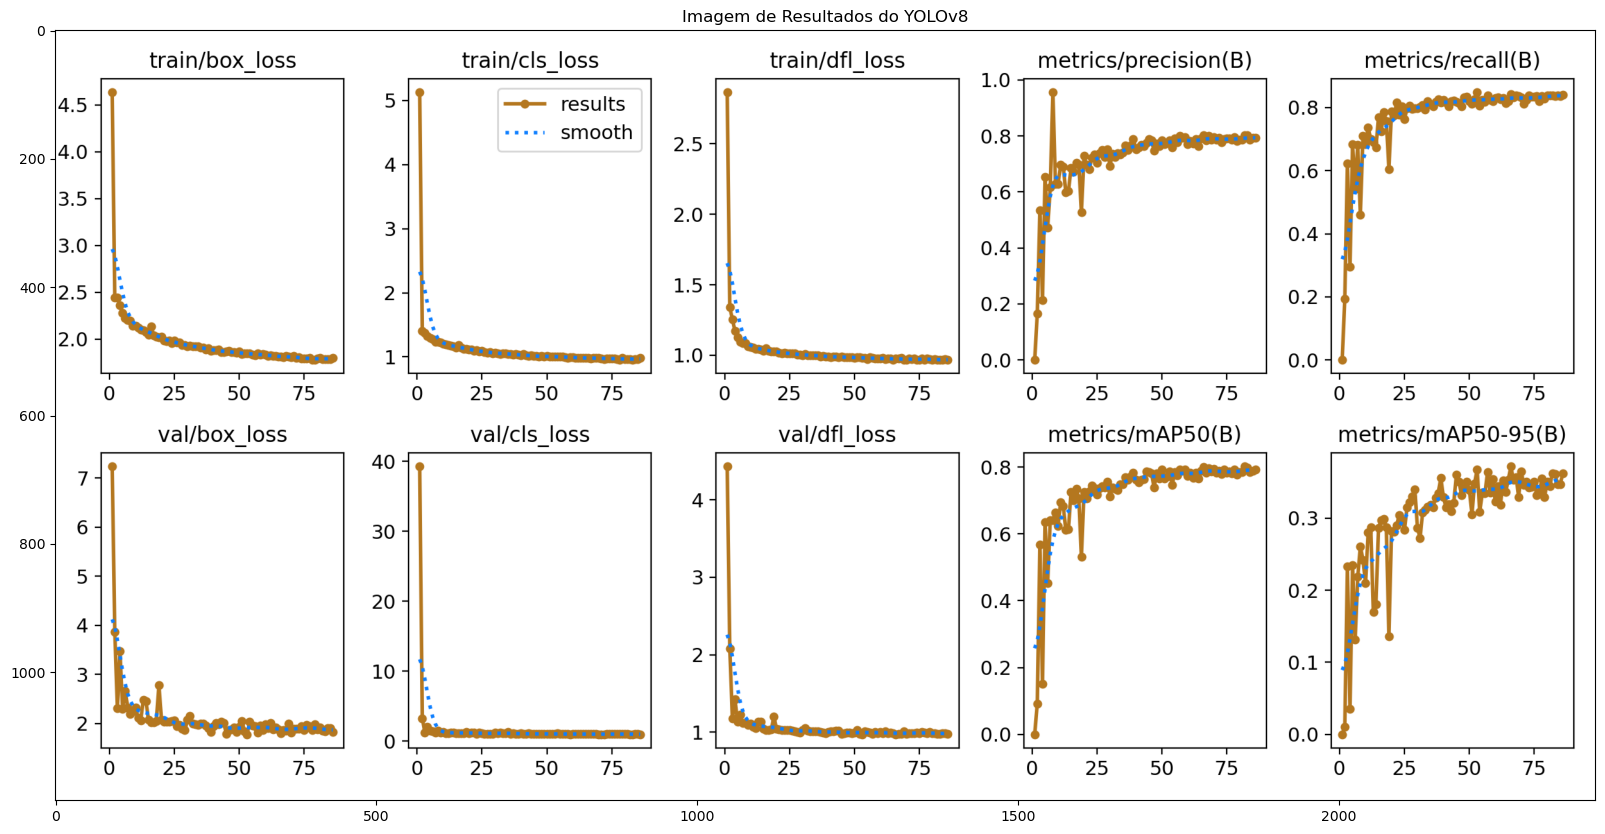

In [ ]:
mostrar(resultados_grafico, "Imagem de Resultados do YOLOv8")

In [ ]:
dir_resultado_val = path+f'/runs/detect/{nome_eval}'
dir_resultado_val

'F:/Yolo_01_06_2024/runs/detect/Falciparum_White_eval'

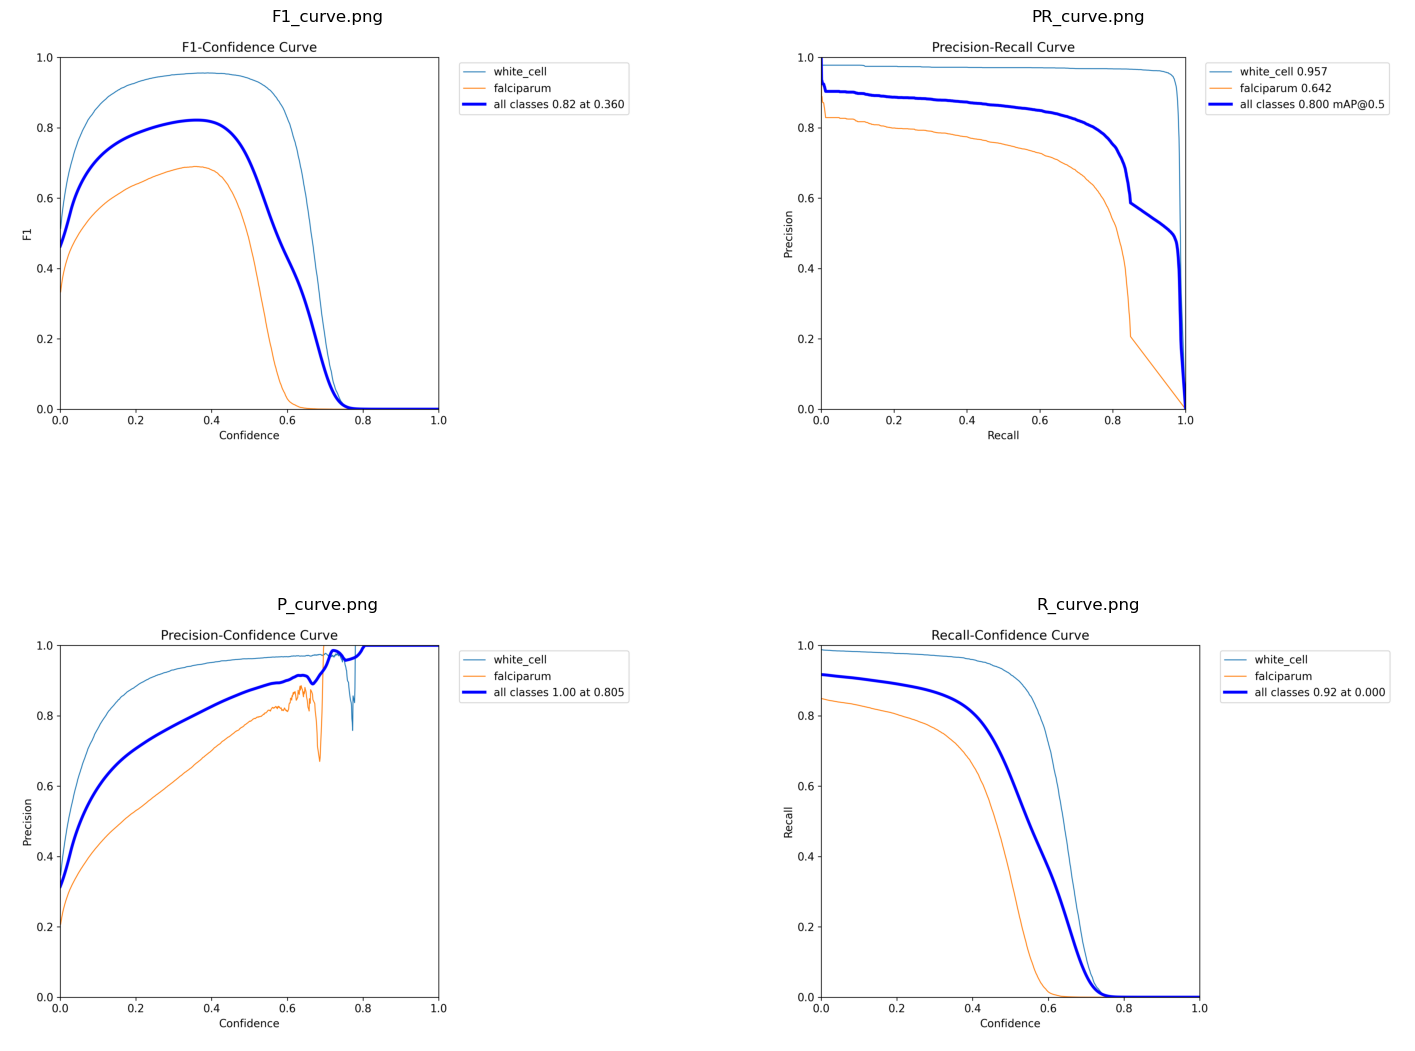

In [ ]:
#Plot para avaliações do modelo
imgs = ['F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']
plt.figure(figsize=(18,14))
for i, img in enumerate(imgs):
  #print(i, img)
  grafico = cv2.imread(os.path.join(dir_resultado_val, img))
  #print(grafico)
  grafico = cv2.cvtColor(grafico, cv2.COLOR_BGR2RGB)
  plt.subplot(2, 2, i + 1)
  plt.title(imgs[i])
  plt.imshow(grafico)
  plt.axis('off')
plt.show()

In [ ]:
matriz_confusao = cv2.imread(os.path.join(dir_resultado_val, 'confusion_matrix.png'))

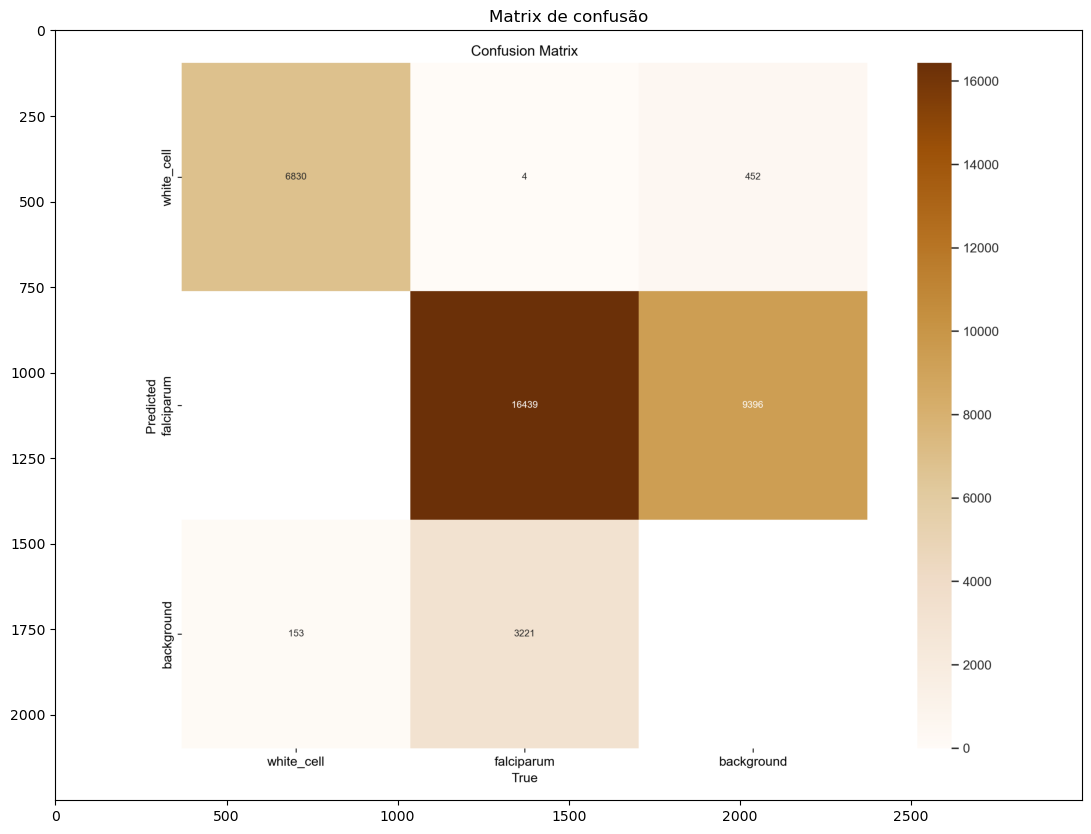

In [ ]:
mostrar(matriz_confusao, 'Matrix de confusão')

# Preparação para predição

In [ ]:
path_detect = '/runs/detect/Falciparum_White'

In [ ]:
best = path+path_detect+ '/weights/best.pt'
best

'F:/Yolo_01_06_2024/runs/detect/Falciparum_White/weights/best.pt'

In [ ]:
# path_image= path+'/dataset/test/images'
# path_image

In [ ]:
%cd {path}

F:\Yolo_01_06_2024


In [ ]:
%ls

 O volume na unidade F ‚ Jogos
 O N£mero de S‚rie do Volume ‚ D65B-C471

 Pasta de F:\Yolo_01_06_2024

05/06/2024  16:18    <DIR>          .
01/06/2024  11:06    <DIR>          Falciparum_WhiteCell
05/06/2024  16:18    <DIR>          runs
05/06/2024  16:17    <DIR>          Runs Antigas
01/06/2024  11:14               161 whitefalc.yaml
02/06/2024  22:03               148 whitefalc1.yaml
01/06/2024  11:20         6.534.387 yolov8n.pt
               3 arquivo(s)      6.534.696 bytes
               4 pasta(s)   283.972.440.064 bytes dispon¡veis


# Predição

In [ ]:
#print("Já executado")
!yolo task=detect mode=predict model={best} source={path_image_test} save=true conf=0.4

Ultralytics YOLOv8.2.2 ðŸš€ Python-3.9.18 torch-2.2.0 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv8n summary (fused): 168 layers, 3006038 parameters, 0 gradients, 8.1 GFLOPs

image 1/6 F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\test\images\TF110_270\20170830_165753.jpg: 640x640 41 white_cells, 65 falciparums, 8.8ms
image 2/6 F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\test\images\TF110_270\20170830_165908.jpg: 640x640 42 white_cells, 37 falciparums, 9.0ms
image 3/6 F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\test\images\TF110_270\20170830_170110.jpg: 640x640 32 white_cells, 82 falciparums, 8.0ms
image 4/6 F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\test\images\TF110_270\20170830_170322.jpg: 640x640 55 white_cells, 59 falciparums, 8.0ms
image 5/6 F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\test\images\TF110_270\20170830_170535.jpg: 640x640 41 white_cells, 83 falciparums, 8.0ms
image 6/6 F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\test\images\TF110_

# Voltar a treinar

In [ ]:
#!yolo task=detect mode=train model={dir_resultado}/weights/last.pt data={arquivo_config} epochs=50

# Resultados de amostras aleatórias

In [ ]:
import random

In [ ]:
dir_predicoes = path+'/runs/detect/predict/'
dir_predicoes

'F:/Yolo_01_06_2024/runs/detect/predict/'

In [ ]:
caminhos = [os.path.join(dir_predicoes, f) for f in os.listdir(dir_predicoes)]
# Número de imagens a plotar
numero_imagens = 5
numeros = list(range(1, len(caminhos)))
numeros_aleatorios = random.sample(numeros, numero_imagens)

print('numeros_aleatorios: ',numeros_aleatorios)


numeros_aleatorios:  [4, 5, 1, 2, 3]


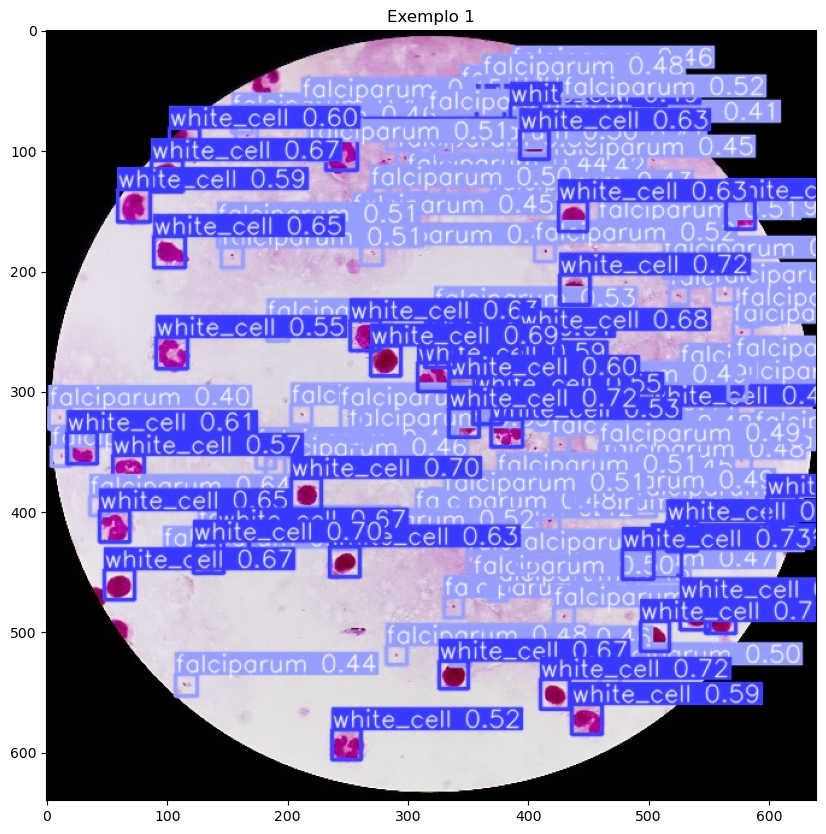

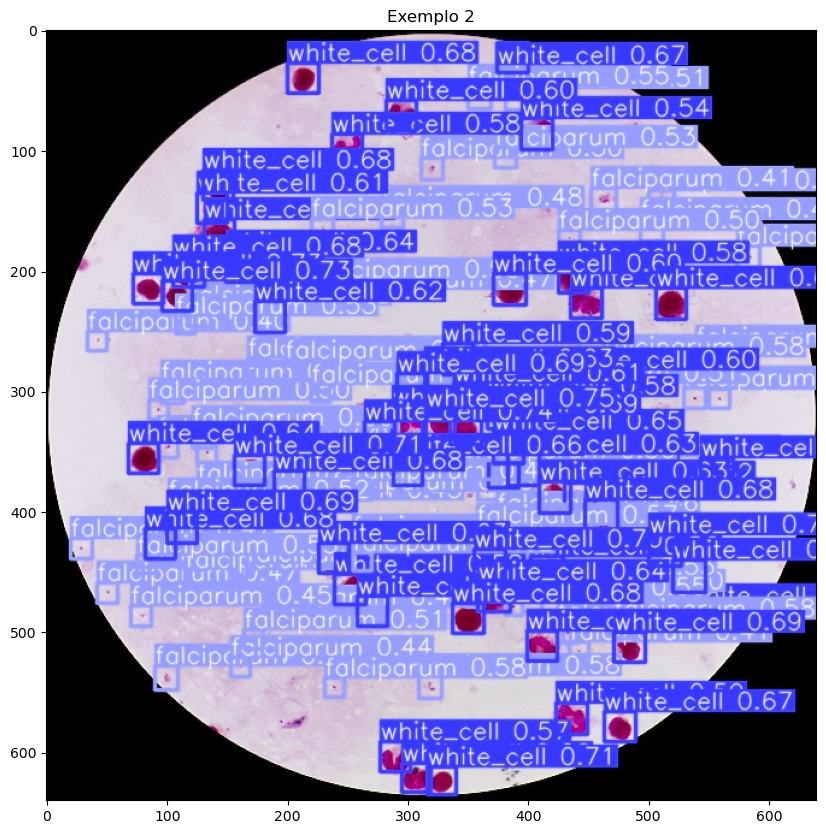

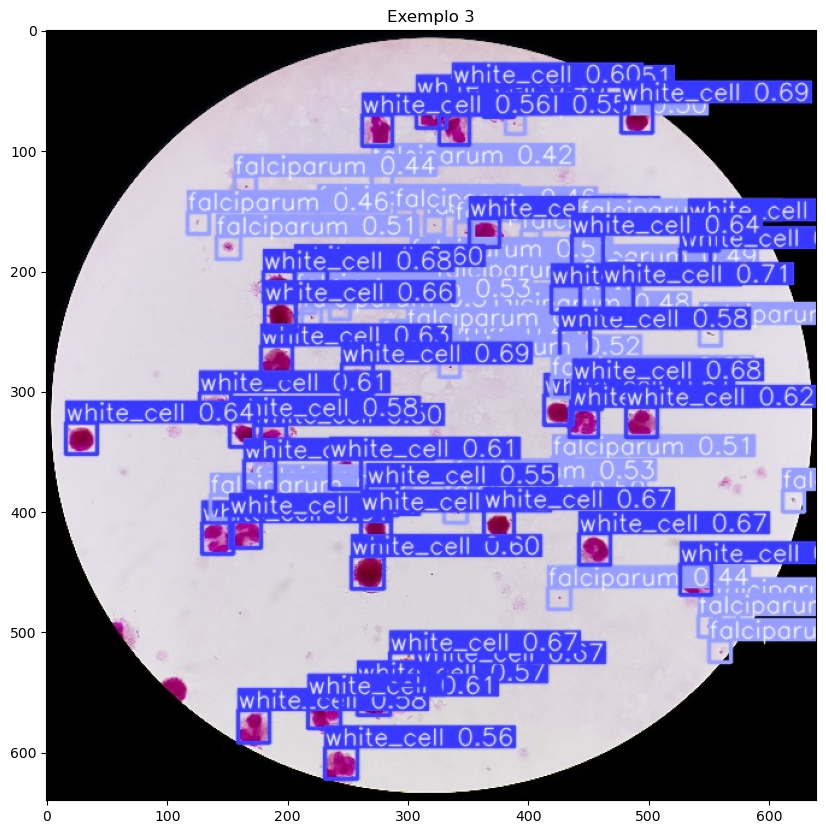

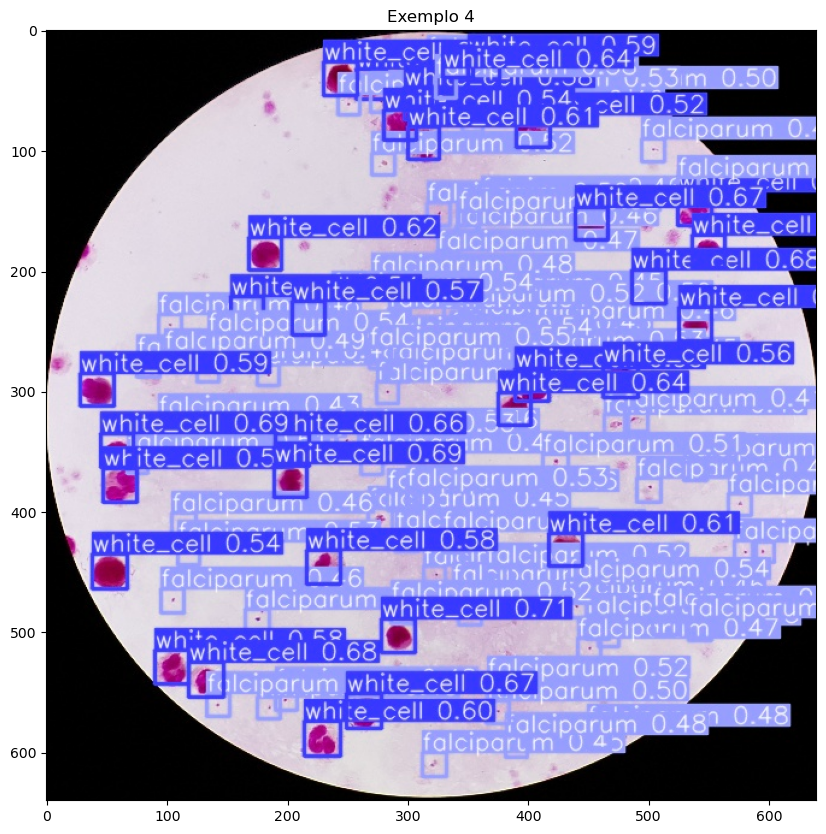

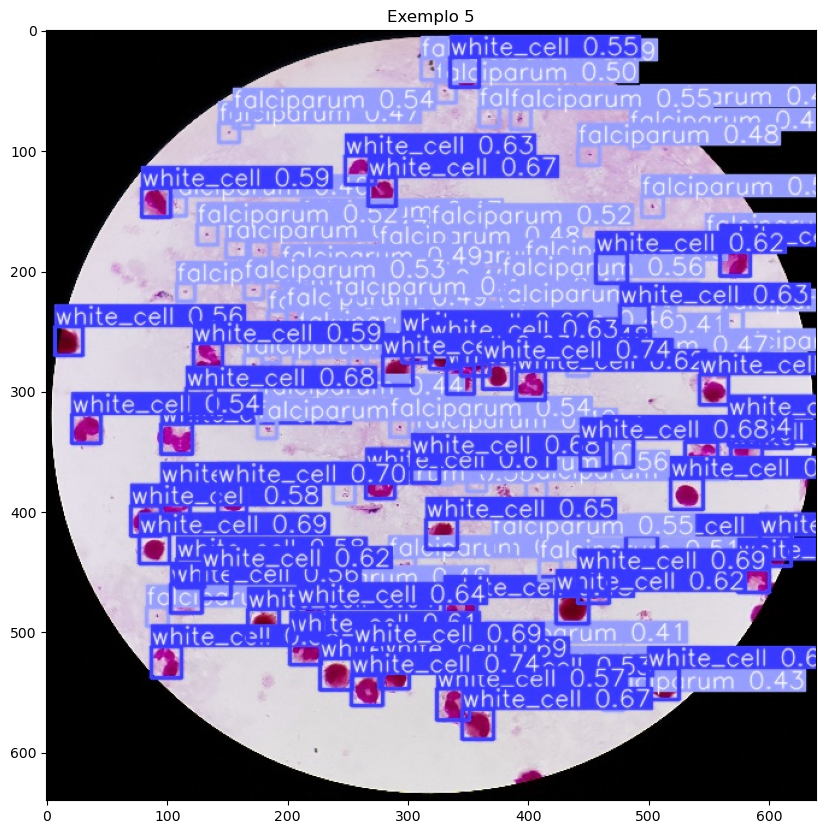

In [ ]:
for i in range(numero_imagens):
    caminho_imagem = caminhos[numeros_aleatorios[i]]
    imagem = cv2.imread(caminho_imagem)
    mostrar(imagem, f"Exemplo {i + 1}")

# Amostras Celular

In [ ]:
amostra_path = 'C:/Users/david/Desktop/Amostra'
amostra_path_640 = f'{amostra_path}/640'
amostra_path_640

'C:/Users/david/Desktop/Amostra/640'

In [ ]:
caminhos = [os.path.join(amostra_path, f) for f in os.listdir(amostra_path)]
caminhos_jpg = [caminho for caminho in caminhos if os.path.isfile(caminho) and os.path.splitext(caminho)[1].lower() == ".jpg"]

In [ ]:
amostra = cv2.imread(caminhos_jpg[0])
mostrar(amostra, 'amostra')

In [ ]:
for caminho in caminhos_jpg:
  i=i+1
  amostra = cv2.imread(caminho)
  amostra = cv2.resize(amostra, (640, 480))
  cv2.imwrite(f"{amostra_path_640}/Amostra640x640{i}.jpg", amostra)

In [ ]:
!yolo task=detect mode=predict model={best} source={amostra_path_640} save=true conf=0.05

Ultralytics YOLOv8.2.2 ðŸš€ Python-3.9.18 torch-2.2.0 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv8n summary (fused): 168 layers, 3006038 parameters, 0 gradients, 8.1 GFLOPs

image 1/5 C:\Users\david\Desktop\Amostra\640\Amostra640x64048.jpg: 480x640 7 white_cells, 9 falciparums, 88.5ms
image 2/5 C:\Users\david\Desktop\Amostra\640\Amostra640x64049.jpg: 480x640 1 white_cell, 7.0ms
image 3/5 C:\Users\david\Desktop\Amostra\640\Amostra640x64050.jpg: 480x640 2 white_cells, 7.0ms
image 4/5 C:\Users\david\Desktop\Amostra\640\Amostra640x64051.jpg: 480x640 2 white_cells, 8 falciparums, 7.0ms
image 5/5 C:\Users\david\Desktop\Amostra\640\Amostra640x64052.jpg: 480x640 1 white_cell, 7.0ms
Speed: 1.4ms preprocess, 23.3ms inference, 185.6ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs\detect\predict2
ðŸ’¡ Learn more at https://docs.ultralytics.com/modes/predict


# Teste com uma imagem


## Classes
---











**Difficult**

Refere-se à dificuldade de identificar ou classificar um parasita da malária em uma imagem de sangue. Isso pode ser devido à baixa qualidade da imagem, à presença de outros elementos no sangue (como glóbulos vermelhos ou plaquetas) ou à morfologia complexa do parasita.

---
**Gametócito**

Forma sexual do parasita da malária que se desenvolve nos glóbulos vermelhos humanos. Os gametócitos são masculinos (microgametócitos) ou femininos (macrogametócitos) e são necessários para a transmissão da malária para mosquitos.


---
**Leucócito -	Glóbulo branco**

Célula do sistema imunológico que ajuda a combater infecções. Os leucócitos podem ser fagócitos (que ingerem e destroem patógenos), linfócitos (que produzem anticorpos) ou células natural killer (que matam células infectadas).


---
**RBC	Glóbulo Vermelho**

Célula sanguínea que transporta oxigênio dos pulmões para o resto do corpo. Os glóbulos vermelhos contêm hemoglobina, uma proteína que se liga ao oxigênio.


---
**Ring**

Estágio inicial do desenvolvimento do parasita da malária dentro do glóbulo vermelho. O parasita aparece como um anel com um núcleo central.


---
**Schizont**

Estágio do desenvolvimento do parasita da malária dentro do glóbulo vermelho. O parasita se divide em vários merozoítos, que são formas jovens que podem infectar outros glóbulos vermelhos.


---
**Trophozoite**

Trofozoíto	Estágio do desenvolvimento do parasita da malária dentro do glóbulo vermelho. O trofozoíto ingere hemoglobina e se multiplica.


---

## Teste individual

In [ ]:
%cd {path_image_test}
%ls

F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\test\images\TF110_270
 O volume na unidade F ‚ Jogos
 O N£mero de S‚rie do Volume ‚ D65B-C471

 Pasta de F:\Yolo_01_06_2024\Falciparum_WhiteCell\dataset\test\images\TF110_270

01/06/2024  11:49    <DIR>          .
01/06/2024  11:58    <DIR>          ..
01/06/2024  11:49           107.837 20170830_165753.jpg
01/06/2024  11:49           100.434 20170830_165908.jpg
01/06/2024  11:49           111.791 20170830_170110.jpg
01/06/2024  11:49           129.205 20170830_170322.jpg
01/06/2024  11:49           126.428 20170830_170535.jpg
01/06/2024  11:49           119.822 20170830_170700.jpg
               6 arquivo(s)        695.517 bytes
               2 pasta(s)   283.965.181.952 bytes dispon¡veis


In [ ]:
%cd {path}

F:\Yolo_01_06_2024


In [ ]:
amostra_path = r'C:\Users\david\Desktop\Amostra'
amostra_path

'C:\\Users\\david\\Desktop\\Amostra'

In [ ]:
amostra = cv2.imread(f'{amostra_path}/Amostra2.jpg')
exemplo = cv2.imread(os.path.join(path_image_test, '20170830_165908.jpg'))
manipulado = cv2.imread(os.path.join(path_image_test, '20170830_165908.jpg'))###################

In [ ]:
#exemplo = cv2.imread('F:/Dataset/Malária/NIH-NLM-ThickBloodSmearsPV_Vivax/NIH-NLM-ThickBloodSmearsPV/Data/test/images/PvTk136/20190809_152247.jpg')

In [ ]:
#Resize the image to 640x640
amostra = cv2.resize(amostra, (480, 640))
cv2.imwrite(f"{amostra_path}/Amostra640x640.jpg", amostra)

True

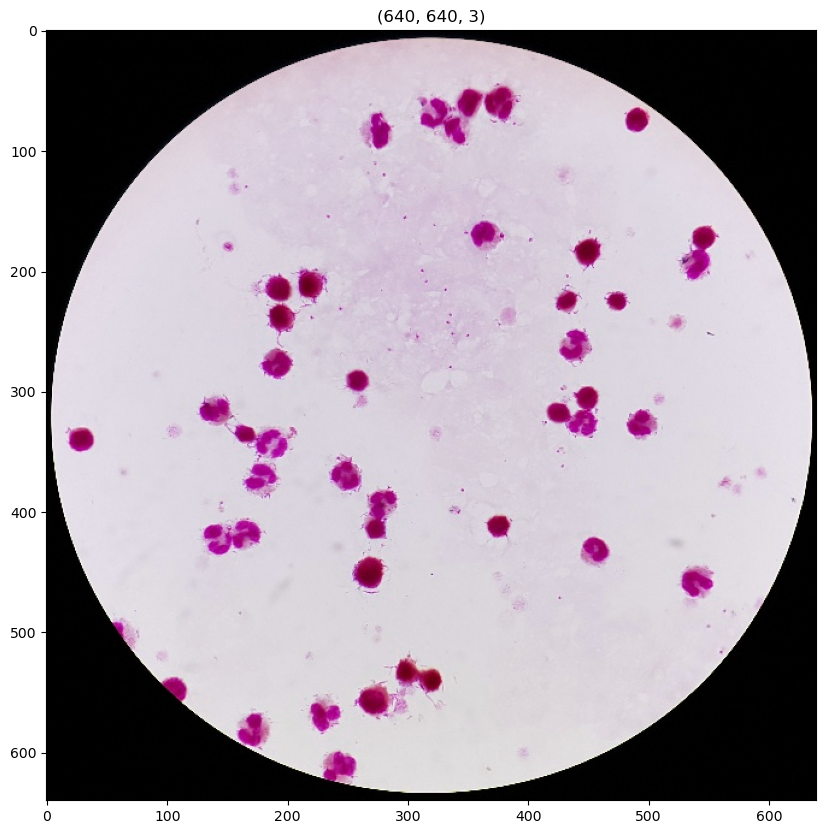

In [ ]:
mostrar(exemplo, exemplo.shape)

In [ ]:
#!yolo task=detect mode=predict model={best} source={path_image_test}/20170830_165908.jpg save=true conf=0.05
#!yolo task=detect mode=predict model={best} source={amostra_path}/Amostra640x640.jpg save=true conf=0.05

Ultralytics YOLOv8.2.2 ðŸš€ Python-3.9.18 torch-2.2.0 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv8n summary (fused): 168 layers, 3006038 parameters, 0 gradients, 8.1 GFLOPs

image 1/1 C:\Users\david\Desktop\Amostra\Amostra640x640.jpg: 640x480 6 falciparums, 94.6ms
Speed: 1.0ms preprocess, 94.6ms inference, 902.1ms postprocess per image at shape (1, 3, 640, 480)
Results saved to runs\detect\predict2
ðŸ’¡ Learn more at https://docs.ultralytics.com/modes/predict


# Recorte

In [ ]:
crop_data_path = path+"/dataset/Crop"
crop_data_path

'F:/Yolo_01_06_2024/dataset/Crop'

In [ ]:
data = True

In [ ]:
# Define as listas de células e suas quantidades
# difficult = []
# gametocito=[]
# leucocito=[]
# ring=[]
white_cell=[]
falciparum =[]
cell_types = ["white_cell","falciparum"]
cell_counts = []
count=0

# Carrega o modelo e executa a inferência
model1 = YOLO(best)  # pretrained YOLOv8n model
results1 = model1([manipulado])  # Guarda em result1 objects Comando tirado(, imgsz=640)
##########################################
boxes = results1[0].boxes.xywh.tolist()
##########################################
# Processa os resultados
boxes_filtered = [box for result in results1 for box in result.boxes if int(box.cls[0].item()) != 3]

for box in boxes_filtered:
  if int(box.cls[0].item()) == 0:
    white_cell.append(box[0].xyxy[0].tolist())
  elif int(box.cls[0].item()) == 1:
     falciparum.append(box[0].xyxy[0].tolist())
  # elif int(box.cls[0].item()) == 2:
  #   leucocito.append(box[0].xyxy[0].tolist())
  # elif int(box.cls[0].item()) == 4:
  #   ring.append(box[0].xyxy[0].tolist())
  # elif int(box.cls[0].item()) == 5:
  #   schizont.append(box[0].xyxy[0].tolist())
  # elif int(box.cls[0].item()) == 6:
  #   trophozoite.append(box[0].xyxy[0].tolist())

# Preenche a lista de quantidades
for cell_type in cell_types:
  # Verifica se a variável associada ao tipo de célula existe
  if locals()[cell_type]:  # Acessa variáveis dinamicamente
    cell_counts.append(len(locals()[cell_type]))
  else:
    cell_counts.append(0)  # Quantidade zero se a lista estiver vazia

# Combina tipos de células e quantidades em uma lista
cell_data = list(zip(cell_types, cell_counts))

# Exibe os resultados
for cell_type, count in cell_data:
  print(f"Quantidade de {cell_type}: {count}")
  print(f"Conteúdo de {cell_type}:")
  for item in locals()[cell_type]:
    print(item)


0: 640x640 45 white_cells, 54 falciparums, 64.5ms
Speed: 7.0ms preprocess, 64.5ms inference, 7.0ms postprocess per image at shape (1, 3, 640, 640)
Quantidade de white_cell: 45
Conteúdo de white_cell:
[462.0401306152344, 211.94906616210938, 487.0810852050781, 236.42910766601562]
[245.67599487304688, 277.3948974609375, 271.3728942871094, 302.9427490234375]
[477.52239990234375, 60.65575408935547, 503.12799072265625, 85.82088470458984]
[437.22686767578125, 291.3372802734375, 461.6497802734375, 315.7139892578125]
[180.27413940429688, 200.20175170898438, 206.58352661132812, 226.45034790039062]
[285.184326171875, 517.9927978515625, 313.1822509765625, 544.6053466796875]
[306.84259033203125, 526.2059936523438, 331.75067138671875, 552.8091430664062]
[363.273193359375, 398.173095703125, 388.9930419921875, 423.9022216796875]
[442.7789306640625, 418.1349792480469, 468.82574462890625, 444.3844909667969]
[181.88922119140625, 226.06243896484375, 207.92718505859375, 251.57318115234375]
[419.2751770019

In [ ]:
# Define cores para cada tipo de célula
cores = {
    "white_cell": (255, 0, 0),  # Vermelho
    "falciparum": (0, 255, 0),  # Verde
    # "leucocito": (0, 0, 255),  # Azul
    # "ring": (255, 255, 0),  # Ciano
    # "schizont": (255, 0, 255),  # Magenta
    # "parazite": (0, 255, 255),  # Amarelo
}
#cores = {"parazite": (0, 255, 255)}  # Amarelo
# Define a espessura da linha
espessura_linha = 1

In [ ]:
cor_circulo = (0, 255, 0)  # Verde

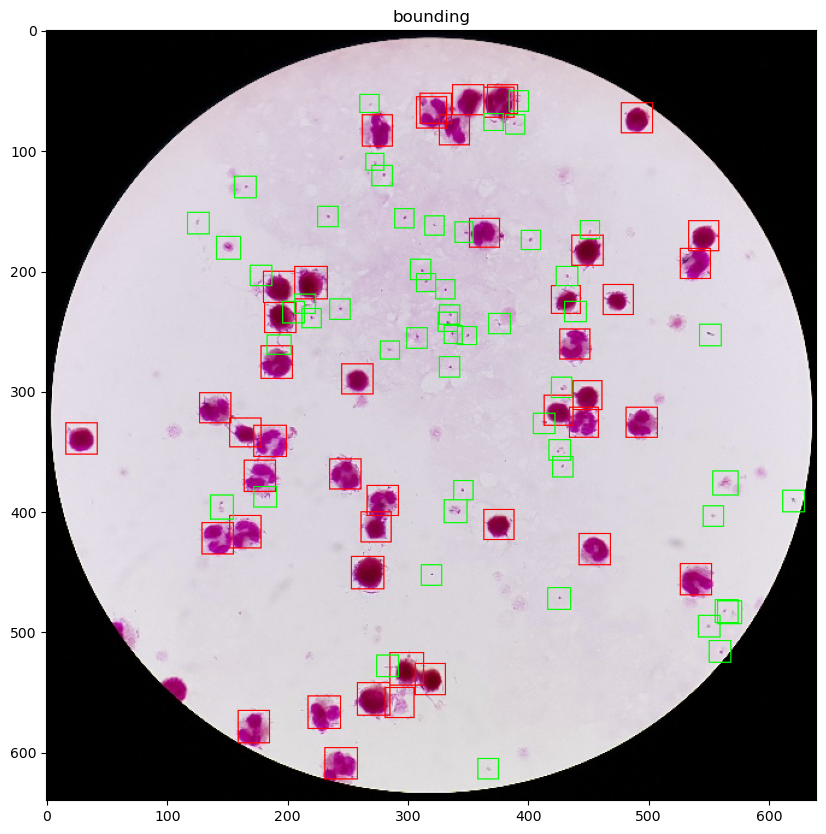

False

In [ ]:
# Loop para recortar e plotar células individualmente
for cell_type, count in cell_data:
  if count > 0:  # Processa apenas células com detecções
    # Cria uma subpasta para cada tipo de célula
    #os.makedirs(f"{crop_data_path}/{cell_type}", exist_ok=True)  # Cria pasta se não existir
    for i, box in enumerate(locals()[cell_type]):
      x1, y1, x2, y2 = box
      # Recorta o objeto usando as coordenadas da caixa delimitadora
      ultralytics_crop_object = exemplo[int(y1):int(y2), int(x1):int(x2)]
      # Redimensionamento da imagem recortada
      #ultralytics_crop_object = cv2.resize(ultralytics_crop_object, dsize=(50, 50))
      # Salva o objeto recortado
      #cv2.imwrite(f"{crop_data_path}/{cell_type}/{cell_type}{i + 1}.jpg", ultralytics_crop_object)

      # Converte a caixa para valores inteiros
      x1, y1, x2, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])

      # Desenha a bounding box na imagem original
      cv2.rectangle(manipulado, (x1, y1), (x2, y2), cores[cell_type], espessura_linha)

      # Desenha o círculo na imagem original
      # centro = (int((x1+x2)//2),int((y1+y2)//2))
      # l = x2 - x1
      # raio = (l + y2 - y1) // 4
      # #cv2.circle(manipulado, centro, raio, cor_circulo, thickness=2)

      # # Plota o objeto recortado
      # plt.figure(figsize=(8, 6))  # Define o tamanho da figura (opcional)
      # plt.imshow(ultralytics_crop_object)
      # plt.title(f"Célula {cell_type} {i + 1}")  # Adiciona título
      # plt.axis('off')  # Desliga rótulos e marcas do eixo
      # plt.show()  # Exibe o gráfico
mostrar(manipulado, "bounding")
cv2.imwrite(f"{crop_data_path}/{cell_type}/bounding.jpg", manipulado)

In [ ]:
# results = model1.predict(exemplo, save_txt=True)


0: 480x640 (no detections), 96.5ms
Speed: 4.1ms preprocess, 96.5ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs\detect\predict4
0 label saved to runs\detect\predict4\labels


In [ ]:
# boxes

[[490.32891845703125, 73.74905395507812, 41.141357421875, 40.542598724365234],
 [267.30517578125, 450.6882629394531, 43.88568115234375, 44.18292236328125],
 [29.039697647094727, 339.88232421875, 41.52103805541992, 41.086669921875],
 [247.82644653320312, 369.076904296875, 41.326904296875, 41.0936279296875],
 [258.3786926269531, 290.79949951171875, 40.55694580078125, 39.918701171875],
 [455.2406005859375, 431.6203308105469, 40.699951171875, 40.07672119140625],
 [545.0653076171875, 171.029052734375, 38.807861328125, 38.10491943359375],
 [375.205810546875, 411.4112548828125, 40.6336669921875, 41.2169189453125],
 [230.06951904296875, 568.436767578125, 44.6895751953125, 43.472412109375],
 [191.48472595214844, 276.753662109375, 42.24945068359375, 42.53240966796875],
 [194.94442749023438, 239.0115966796875, 43.693603515625, 42.3829345703125],
 [449.15362548828125, 183.6690673828125, 39.5399169921875, 39.4530029296875],
 [538.9398193359375, 457.262451171875, 41.072021484375, 40.69952392578125],

In [ ]:
# cor_circulo = (0, 255, 0)  # Verde
# numero=0
# for resultado in boxes:
#   #if numero == len(boxes)-1:
#     x, y, w, h = resultado
#     centro = (int(x),int(y))
#     raio = int(w / 2)
#     cv2.circle(manipulado, centro, raio, cor_circulo, thickness=1)
#     #print("Igual")
#   #else:
#    # numero=numero+1
# mostrar(manipulado,'Bla')
# print(f'Valor de X: {x}\nValor de Y: {y}\nValor de W: {w}\nValor de H: {h}\nValor de Centro: {centro}')

In [ ]:
# results1[0].boxes

# Por equanto lixo